## Statistical Modelling. Lecture 8 Example

**Multiple Linear Regression**

Diagnostics and Model Building

---

We want to find a "best" model for predicting miles per gallon based on the given data. The data concerns city-cycle fuel consumption in miles per gallon, to be predicted in terms of 3 multivalued discrete and 5 continuous attributes:

- ``mpg`` - miles per gallon: continuous
- ``cyl`` - cylinders: multi-valued discrete
- ``disp`` - displacement: continuous
- ``hp`` - horsepower: continuous
- ``wt`` -  weight: continuous
- ``acc`` - acceleration: continuous
- ``year`` - model year: multi-valued discrete
- ``origin`` - car origin: multi-valued discrete
- ``name`` - car name: string (unique for each instance)

Data source: [Marchine Learning Repository](https://archive.ics.uci.edu/ml/datasets/auto+mpg)

---

### Step 1.

Read and visually inspect the data. Fit a model based on observations. Add new terms to the model and/or make transformations of variables, if needed.

In [1]:
auto = read.csv("https://raw.githubusercontent.com/uqglmn/sm/main/mlr/auto.csv")
str(auto)

'data.frame':	392 obs. of  9 variables:
 $ mpg   : num  18 15 18 16 17 15 14 14 14 15 ...
 $ cyl   : int  8 8 8 8 8 8 8 8 8 8 ...
 $ disp  : num  307 350 318 304 302 429 454 440 455 390 ...
 $ hp    : int  130 165 150 150 140 198 220 215 225 190 ...
 $ wt    : int  3504 3693 3436 3433 3449 4341 4354 4312 4425 3850 ...
 $ acc   : num  12 11.5 11 12 10.5 10 9 8.5 10 8.5 ...
 $ year  : int  70 70 70 70 70 70 70 70 70 70 ...
 $ origin: int  1 1 1 1 1 1 1 1 1 1 ...
 $ name  : chr  "chevrolet chevelle malibu" "buick skylark 320" "plymouth satellite" "amc rebel sst" ...


In [2]:
auto$cyl = as.factor(auto$cyl)
auto$origin = as.factor(auto$origin)
str(auto)

'data.frame':	392 obs. of  9 variables:
 $ mpg   : num  18 15 18 16 17 15 14 14 14 15 ...
 $ cyl   : Factor w/ 5 levels "3","4","5","6",..: 5 5 5 5 5 5 5 5 5 5 ...
 $ disp  : num  307 350 318 304 302 429 454 440 455 390 ...
 $ hp    : int  130 165 150 150 140 198 220 215 225 190 ...
 $ wt    : int  3504 3693 3436 3433 3449 4341 4354 4312 4425 3850 ...
 $ acc   : num  12 11.5 11 12 10.5 10 9 8.5 10 8.5 ...
 $ year  : int  70 70 70 70 70 70 70 70 70 70 ...
 $ origin: Factor w/ 3 levels "1","2","3": 1 1 1 1 1 1 1 1 1 1 ...
 $ name  : chr  "chevrolet chevelle malibu" "buick skylark 320" "plymouth satellite" "amc rebel sst" ...


#### Step 1.1. Raw data analysis

In [3]:
# a function that computes correlations
panel.cor = function(x, y, ...)
{
  par(usr = c(0, 1, 0, 1))
  txt = as.character(format(cor(x, y), digits=2))
  text(0.5, 0.5, txt, cex=2.5)
}

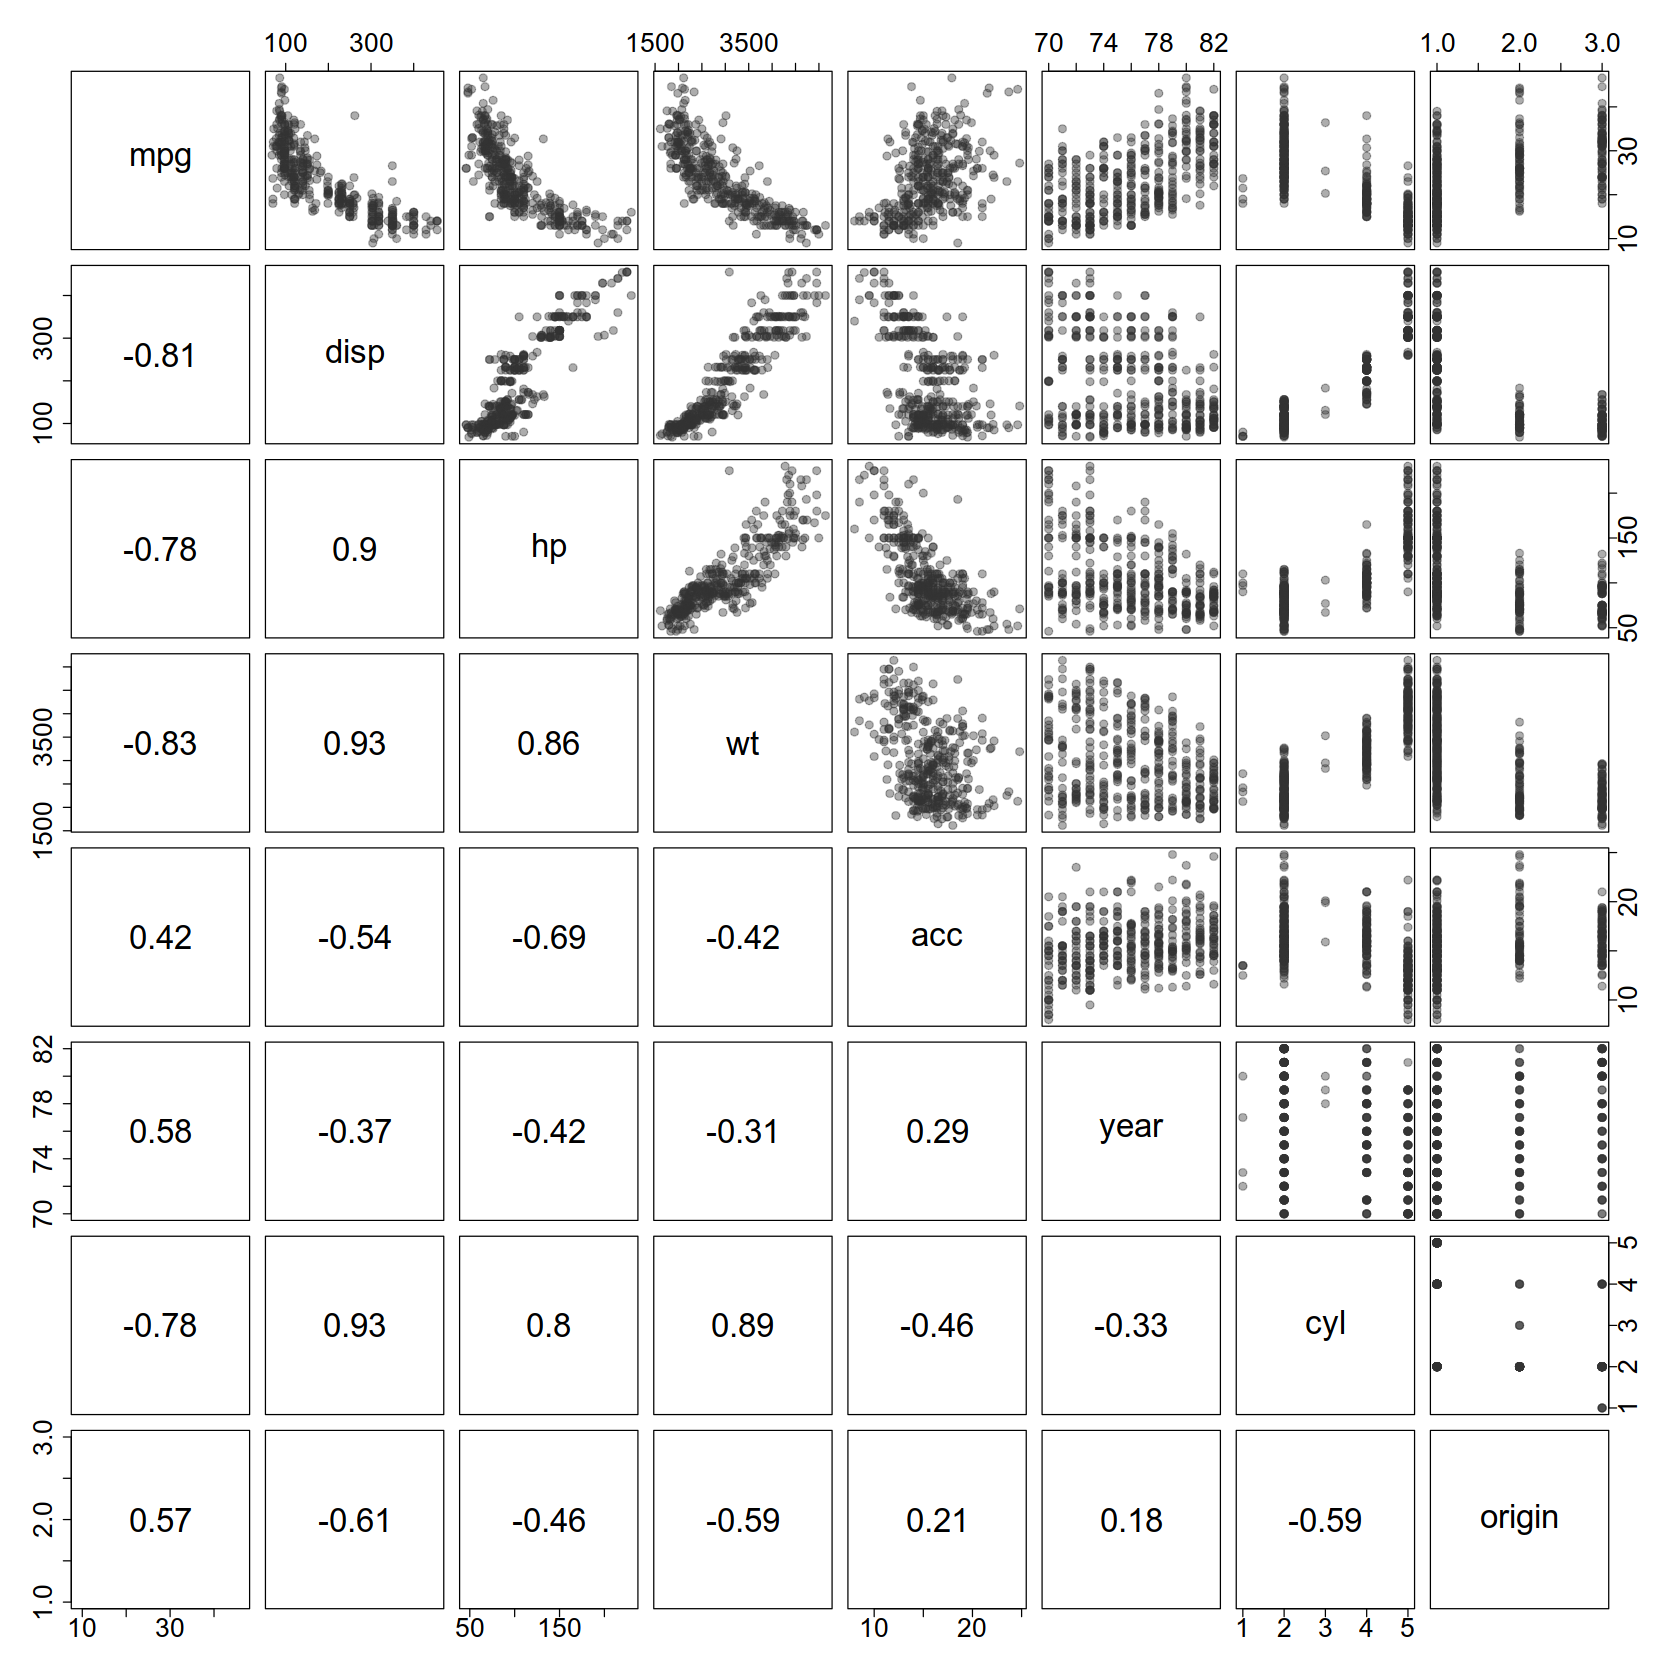

In [4]:
options(repr.plot.width=14, repr.plot.height=14)

pairs(mpg ~ disp + hp + wt + acc + year + cyl + origin, data=auto, 
      lower.panel=panel.cor, 
      cex.labels=2.5,
      cex=2,
      cex.axis=2,
      pch=20, 
      col=rgb(red=0.2, green=0.2, blue=0.2, alpha=0.4)
     )

In [5]:
model = lm(mpg ~ disp + hp + wt + acc + year + cyl + origin, data=auto)
summary(model)


Call:
lm(formula = mpg ~ disp + hp + wt + acc + year + cyl + origin, 
    data = auto)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.6797 -1.9373 -0.0678  1.6711 12.7756 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2.208e+01  4.541e+00  -4.862 1.70e-06 ***
disp         1.870e-02  7.222e-03   2.590  0.00997 ** 
hp          -3.490e-02  1.323e-02  -2.639  0.00866 ** 
wt          -5.780e-03  6.315e-04  -9.154  < 2e-16 ***
acc          2.598e-02  9.304e-02   0.279  0.78021    
year         7.370e-01  4.892e-02  15.064  < 2e-16 ***
cyl4         6.722e+00  1.654e+00   4.064 5.85e-05 ***
cyl5         7.078e+00  2.516e+00   2.813  0.00516 ** 
cyl6         3.351e+00  1.824e+00   1.837  0.06701 .  
cyl8         5.099e+00  2.109e+00   2.418  0.01607 *  
origin2      1.764e+00  5.513e-01   3.200  0.00149 ** 
origin3      2.617e+00  5.272e-01   4.964 1.04e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard er

In [6]:
# a short-cut function for a residual plot with a trend line
resplot = function(x, y, xlab, ylab)
{
    plot(x, y, 
         main=paste(ylab, "vs", xlab),    # title
         xlab=xlab, ylab=ylab,            # x and y labels
         cex.main=1, font.main=1,         # adjust font sizes
        )
    new.x = seq(min(x), max(x), length.out=50)
    lines(new.x, predict(loess(y~x), newdata=data.frame(x=new.x)), col=2, lwd=2) # add smooth trendline
}

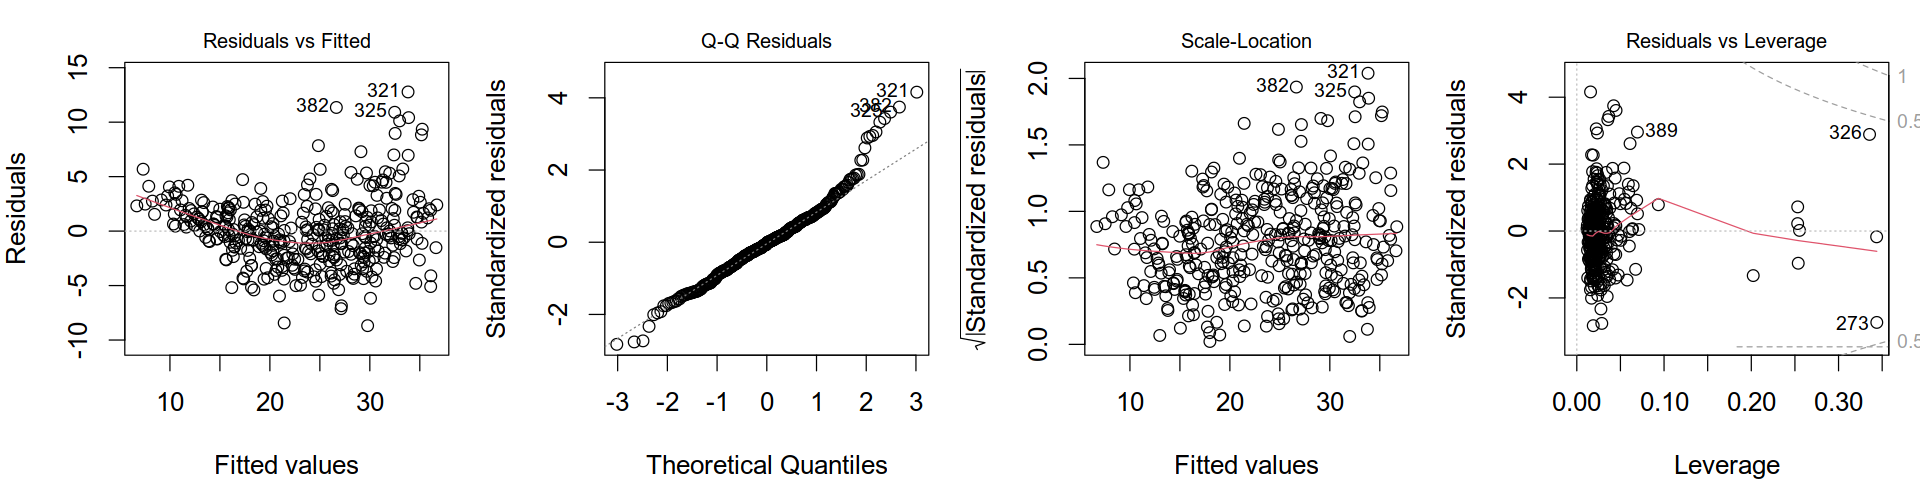

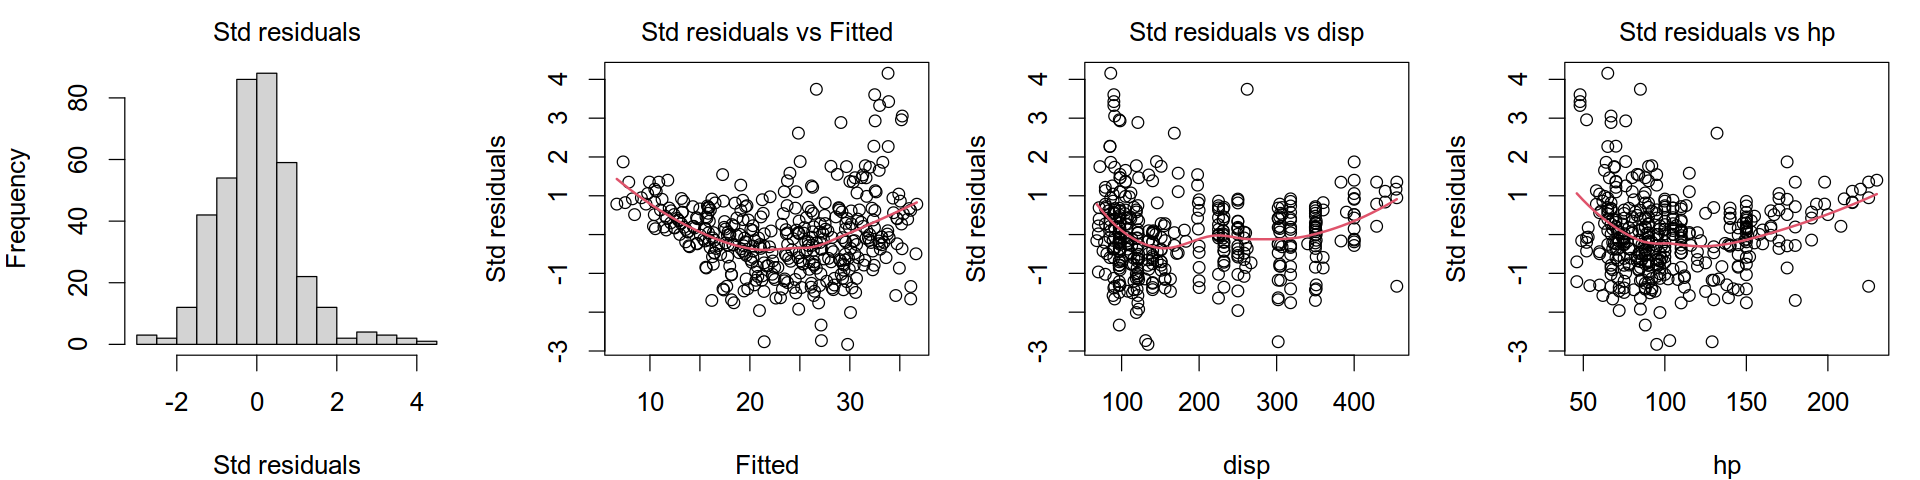

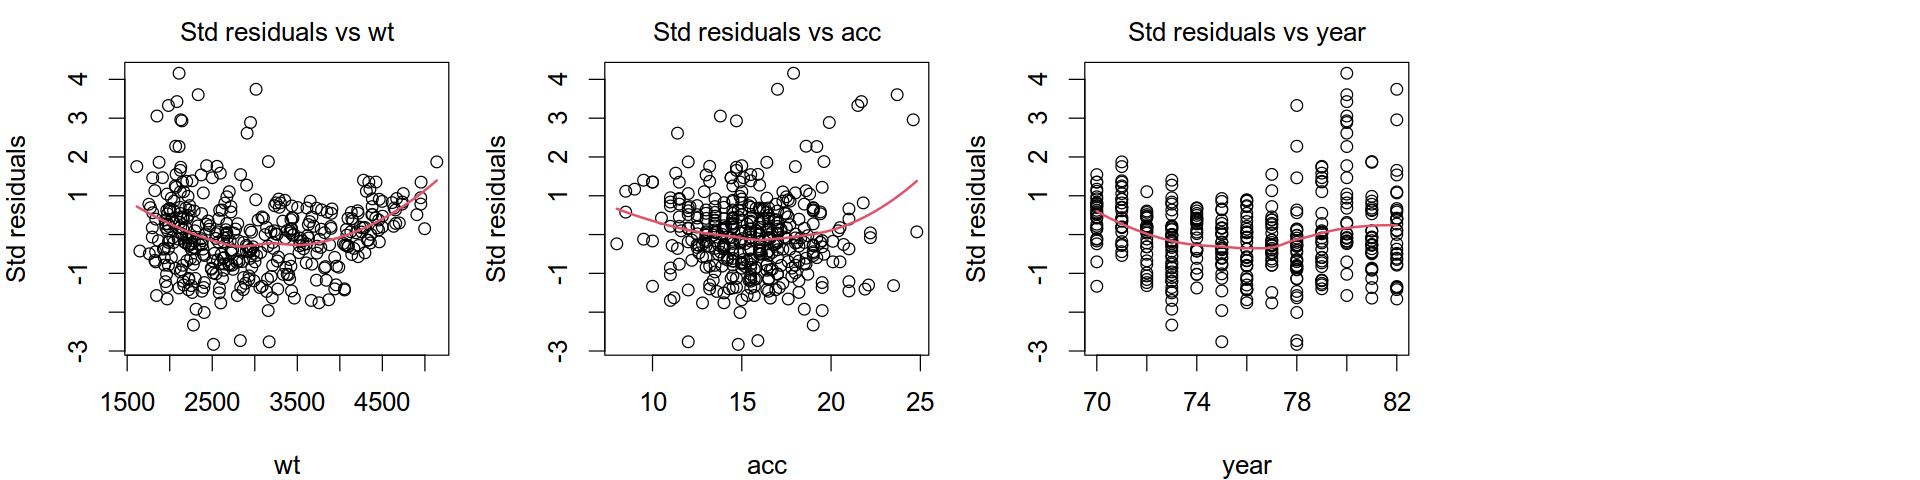

In [7]:
options(repr.plot.width=16, repr.plot.height=4)
par(mfrow = c(1, 4), mar=c(4,4,2,1), cex=1.3)

plot(model)
r.std = rstandard(model)
y.hat = fitted(model)
with(auto,{
    hist(r.std, main="Std residuals", cex.main=1, font.main = 1, xlab = "Std residuals")
    resplot(y.hat, r.std, xlab = "Fitted", ylab="Std residuals")
    resplot(disp, r.std, xlab = "disp", ylab="Std residuals")
    resplot(hp, r.std, xlab = "hp", ylab="Std residuals")
    resplot(wt, r.std, xlab = "wt", ylab="Std residuals")
    resplot(acc, r.std, xlab = "acc", ylab="Std residuals")
    resplot(year, r.std, xlab = "year", ylab="Std residuals")
    }
)

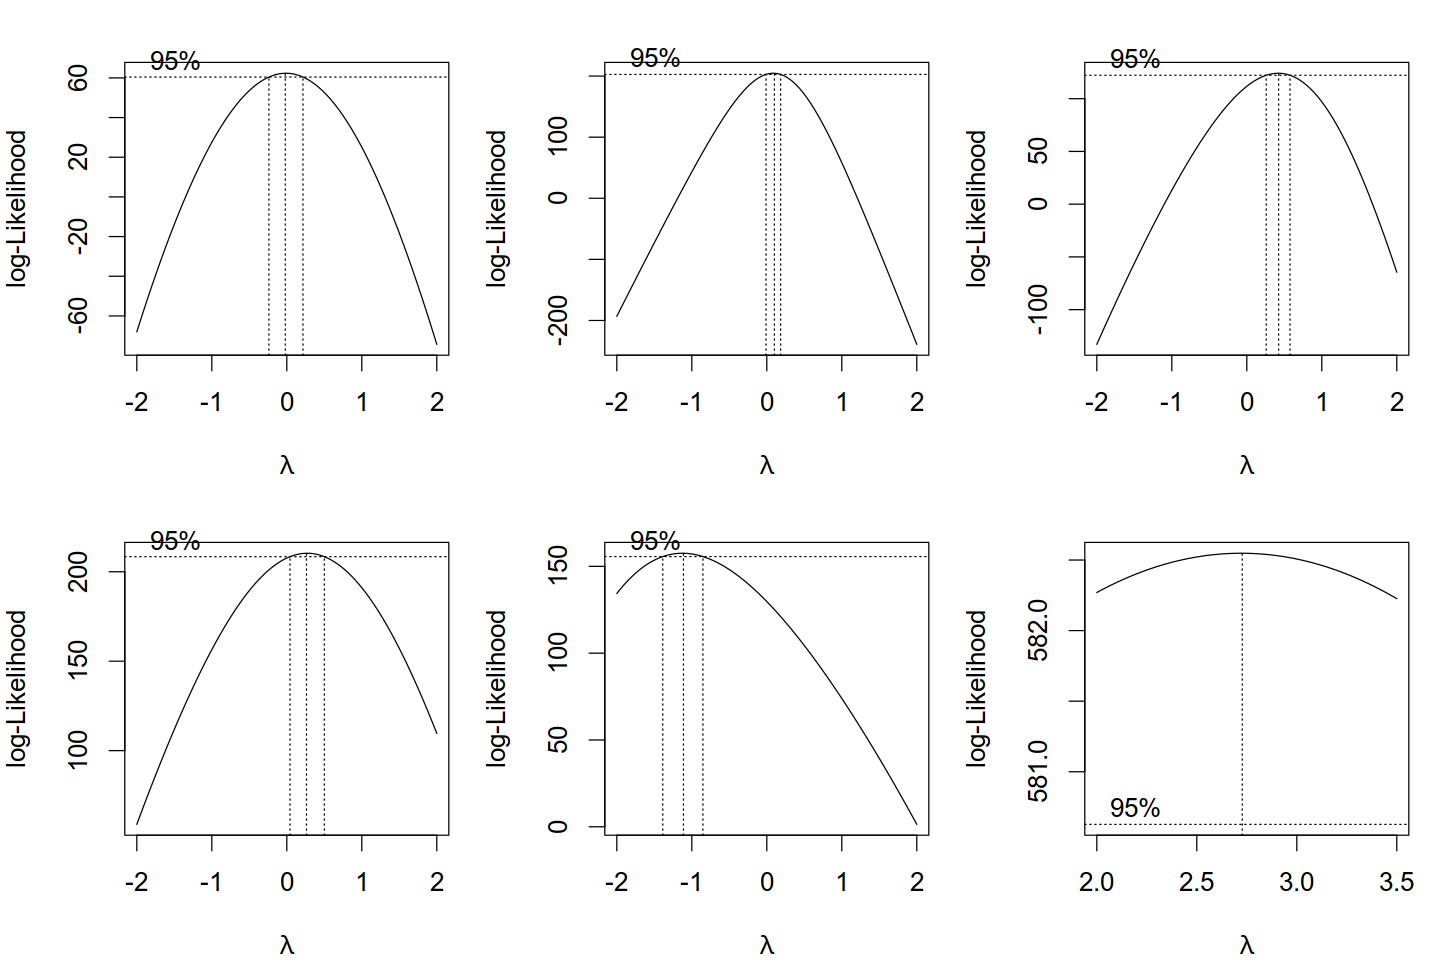

In [8]:
# initial boxcox analysis
library(MASS)
options(repr.plot.width=12, repr.plot.height=8)
par(mfrow = c(2, 3), mar=c(4,4,2,1), cex=1.3)
boxcox(mpg~., data=auto)
boxcox(disp~., data=auto)
boxcox(hp~., data=auto)
boxcox(wt~., data=auto)
boxcox(acc~., data=auto)
boxcox(year~., data=auto, seq(2,3.5,0.1))

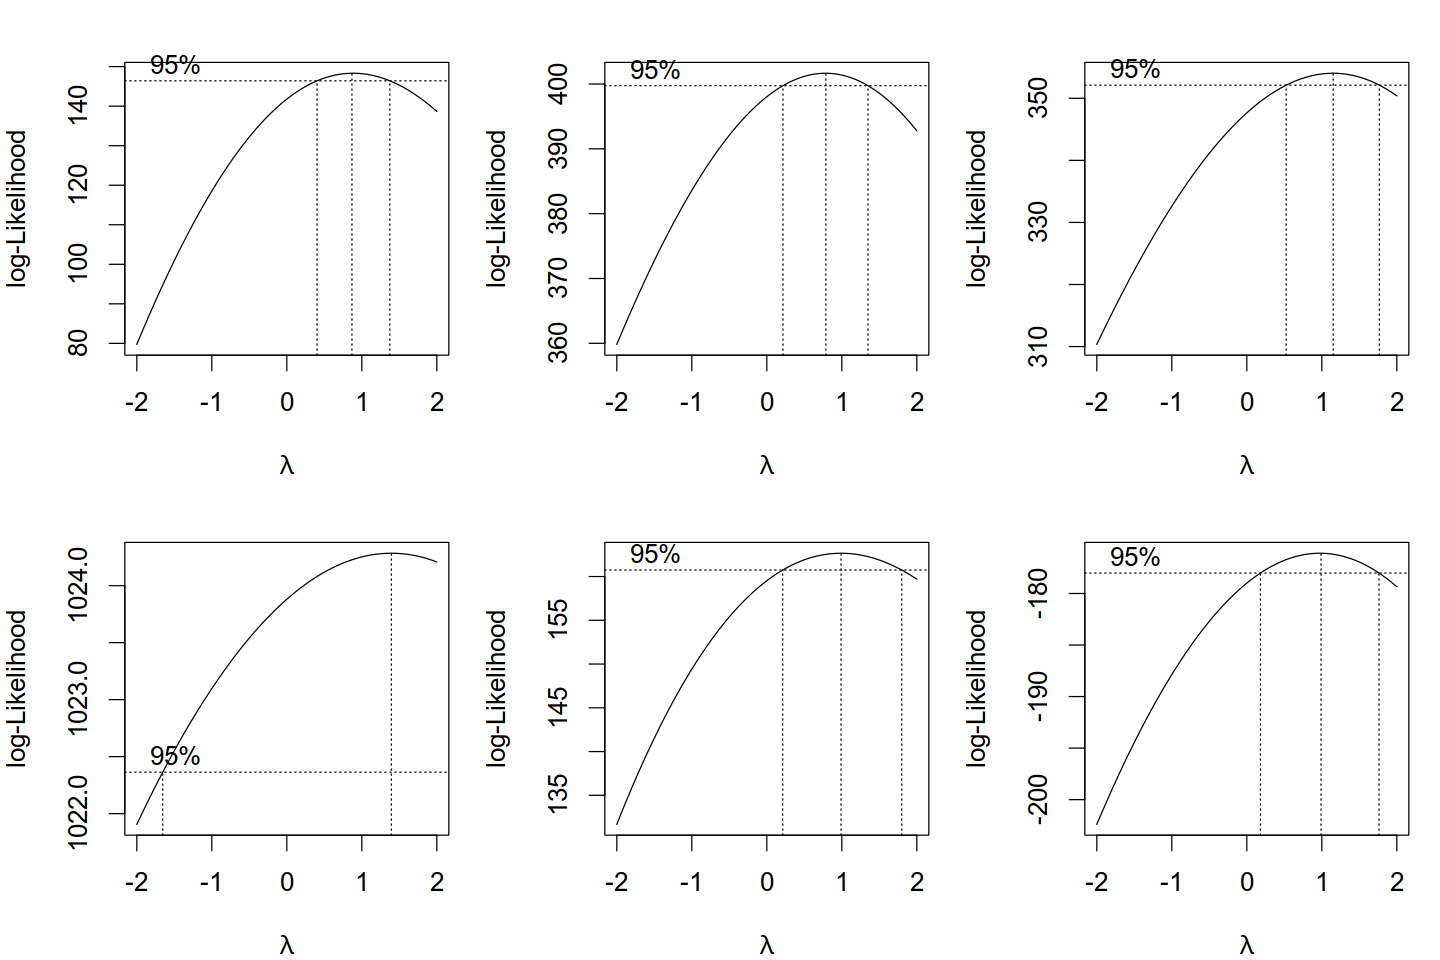

In [9]:
# best boxcox analysis
library(MASS)
options(repr.plot.width=12, repr.plot.height=8)
par(mfrow = c(2, 3), mar=c(4,4,2,1), cex=1.3)
boxcox(log(mpg)~log(disp)+log(hp)+log(log(wt))+log(acc)+I(year^2.5)+cyl+origin, data=auto)
boxcox(log(disp)~log(mpg)+log(hp)+log(log(wt))+log(acc)+I(year^2.5)+cyl+origin, data=auto)
boxcox(log(hp)~log(mpg)+log(disp)+log(log(wt))+log(acc)+I(year^2.5)+cyl+origin, data=auto)
boxcox(log(log(wt))~log(mpg)+log(disp)+log(hp)+log(acc)+I(year^2.5)+cyl+origin, data=auto)
boxcox(log(acc)~log(mpg)+log(disp)+log(hp)+log(log(wt))+I(year^2.5)+cyl+origin, data=auto)
boxcox(I(year^2.5)~log(mpg)+log(disp)+log(hp)+log(log(wt))+log(acc)+cyl+origin, data=auto)

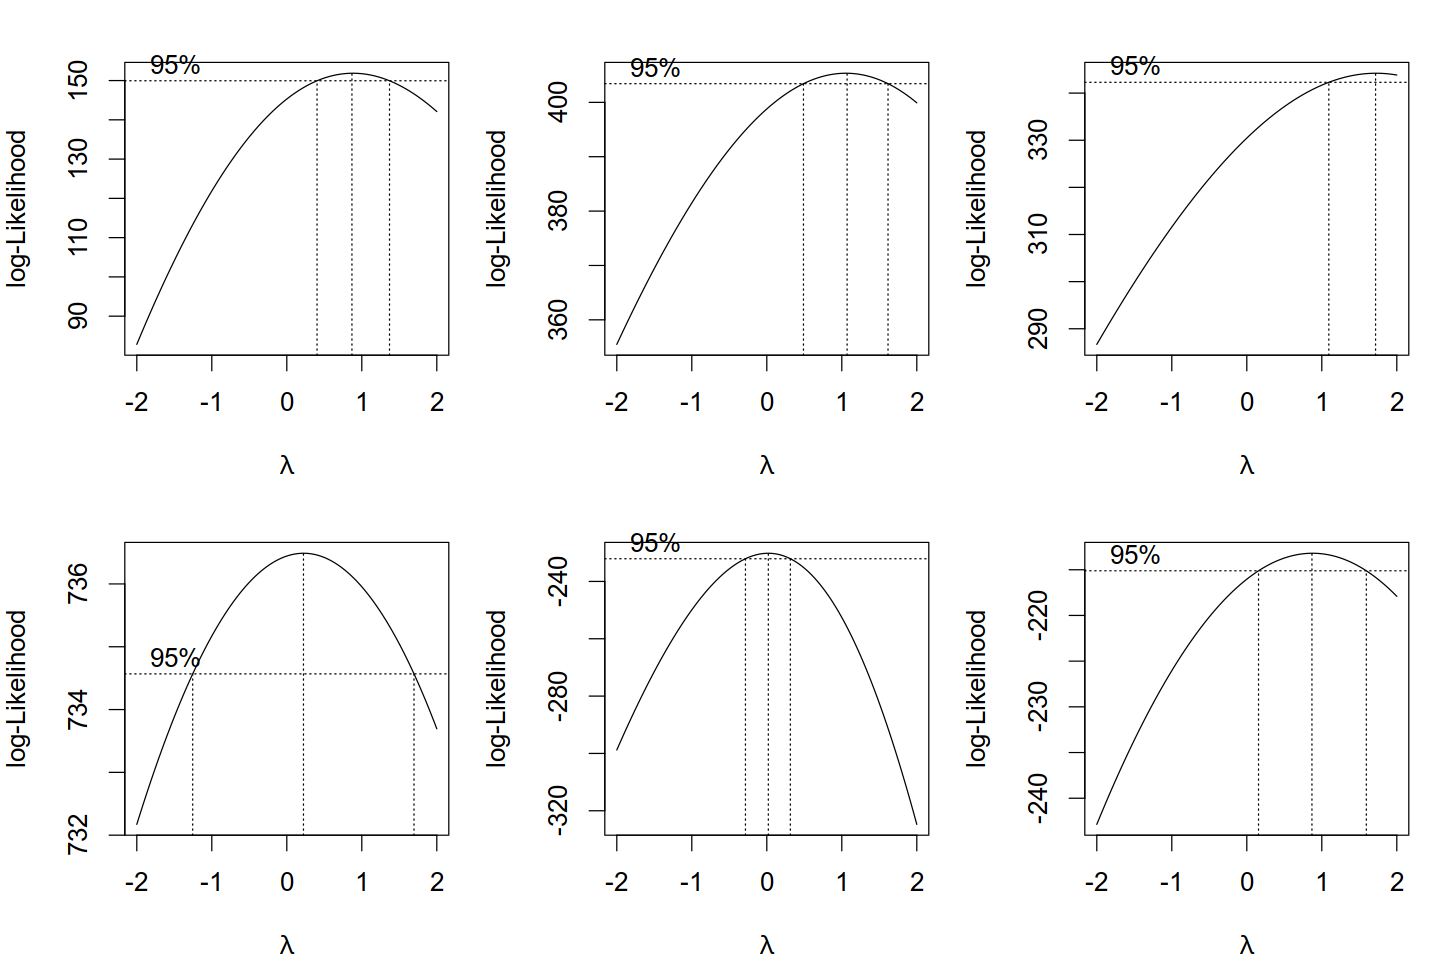

In [10]:
# final boxcox analysis
library(MASS)
options(repr.plot.width=12, repr.plot.height=8)
par(mfrow = c(2, 3), mar=c(4,4,2,1), cex=1.3)
boxcox(log(mpg) ~ log(disp) + log(hp) + log(wt) + I(1/acc) + I(year^2.75) + cyl + origin, data=auto)
boxcox(log(disp) ~ log(mpg) + log(hp) + log(wt) + I(1/acc) + I(year^2.75) + cyl + origin, data=auto)
boxcox(log(hp) ~ log(mpg) + log(disp) + log(wt) + I(1/acc) + I(year^2.75) + cyl + origin, data=auto)
boxcox(log(wt) ~ log(mpg) + log(disp) + log(hp) + I(1/acc) + I(year^2.75) + cyl + origin, data=auto)
boxcox(I(1/acc) ~ log(mpg) + log(disp) + log(hp) + log(wt) + I(year^2.75) + cyl + origin, data=auto)
boxcox(I(year^2.75) ~ log(mpg) + log(disp) + log(hp) + log(wt) + I(1/acc) + cyl + origin, data=auto)

The final boxcox analysis suggests further transformations, however, these ensure validity of normality assumptions and lead to the most accurate model.

#### Step 1.2. Transformed data analysis

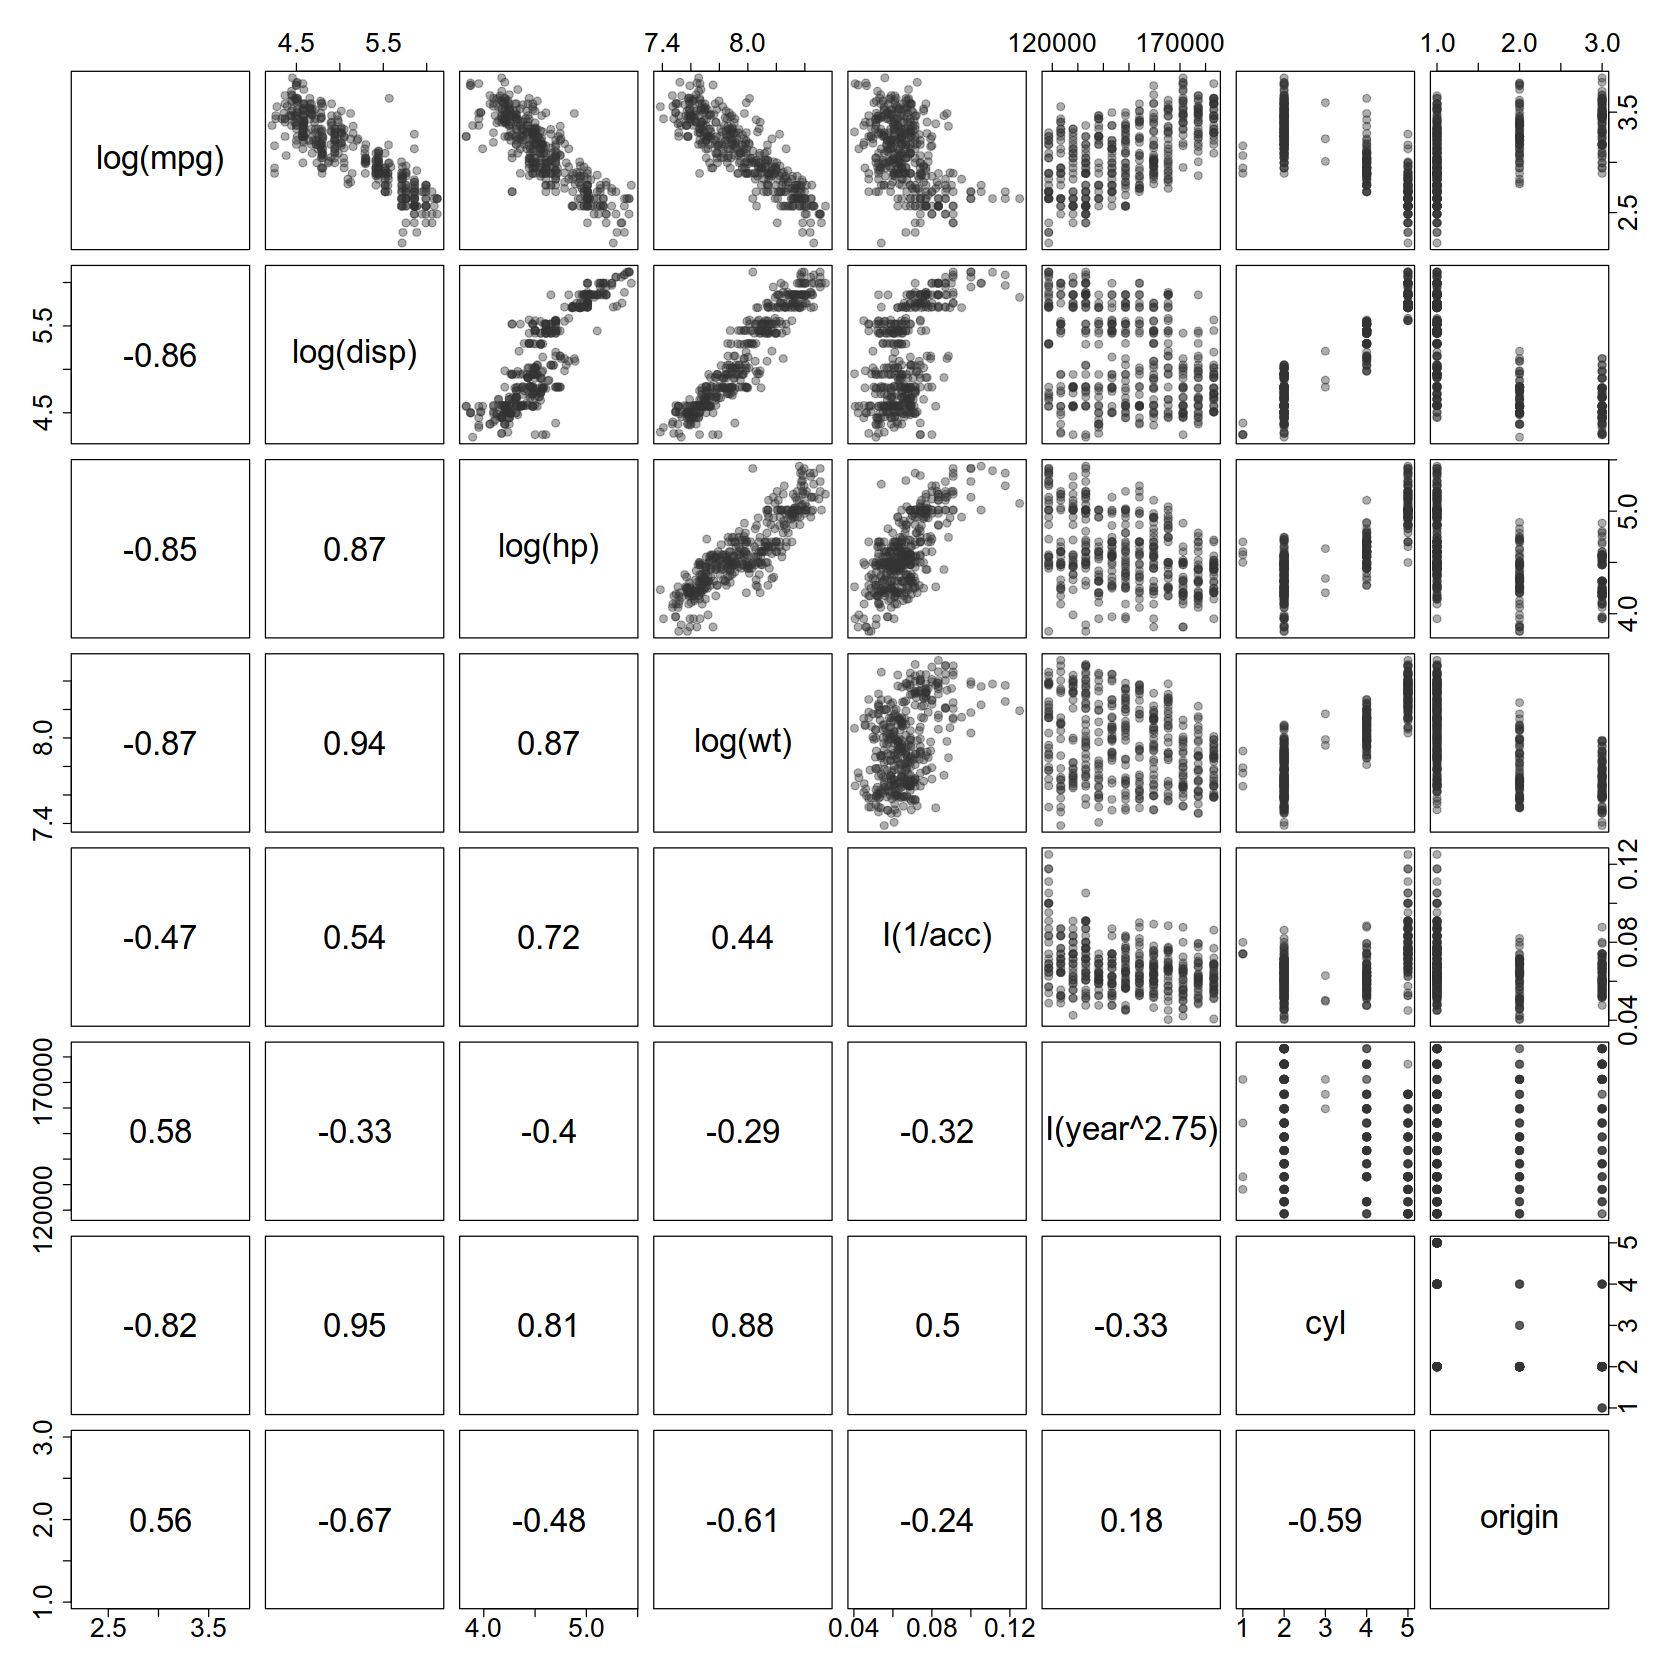

In [11]:
options(repr.plot.width=14, repr.plot.height=14)

pairs(log(mpg) ~ log(disp) + log(hp) + log(wt) + I(1/acc) + I(year^2.75) + cyl + origin, data=auto, 
      lower.panel=panel.cor, 
      cex.labels=2.5,
      cex=2,
      cex.axis=2,
      pch=20, 
      col=rgb(red=0.2, green=0.2, blue=0.2, alpha=0.4)
     )

In [12]:
model = lm(log(mpg) ~ log(disp) + log(hp) + log(wt) + I(1/acc) + I(year^2.75) + cyl + origin, data=auto)
summary(model)


Call:
lm(formula = log(mpg) ~ log(disp) + log(hp) + log(wt) + I(1/acc) + 
    I(year^2.75) + cyl + origin, data = auto)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.34456 -0.06402 -0.00145  0.05530  0.42704 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   6.993e+00  4.343e-01  16.102  < 2e-16 ***
log(disp)    -6.998e-02  5.903e-02  -1.185 0.236614    
log(hp)      -3.098e-01  5.375e-02  -5.764 1.70e-08 ***
log(wt)      -4.337e-01  8.529e-02  -5.085 5.79e-07 ***
I(1/acc)      3.639e+00  8.409e-01   4.328 1.93e-05 ***
I(year^2.75)  5.468e-06  3.132e-07  17.461  < 2e-16 ***
cyl4          2.983e-01  6.244e-02   4.778 2.53e-06 ***
cyl5          3.578e-01  9.211e-02   3.885 0.000121 ***
cyl6          2.422e-01  7.354e-02   3.294 0.001080 ** 
cyl8          2.308e-01  8.029e-02   2.875 0.004272 ** 
origin2       2.067e-02  2.066e-02   1.001 0.317656    
origin3       4.424e-02  1.964e-02   2.253 0.024828 *  
---
Signif. codes:  0 ‘***’ 0.00

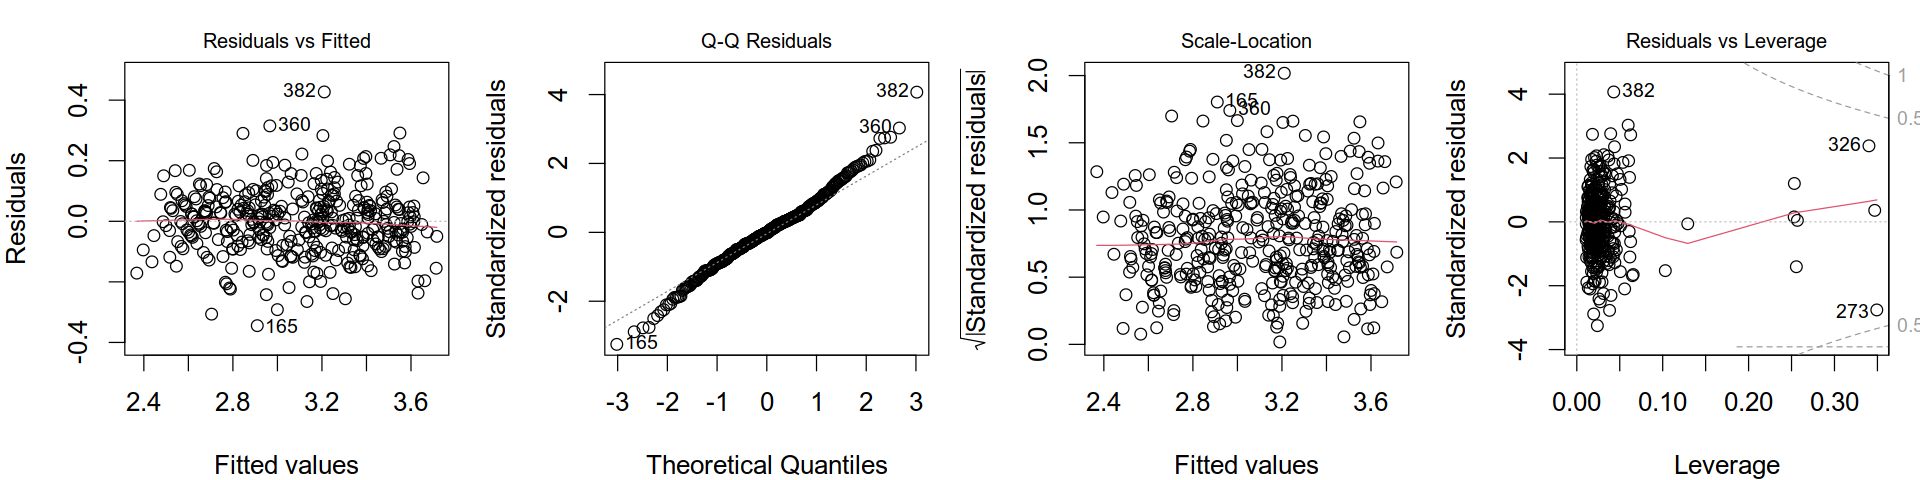

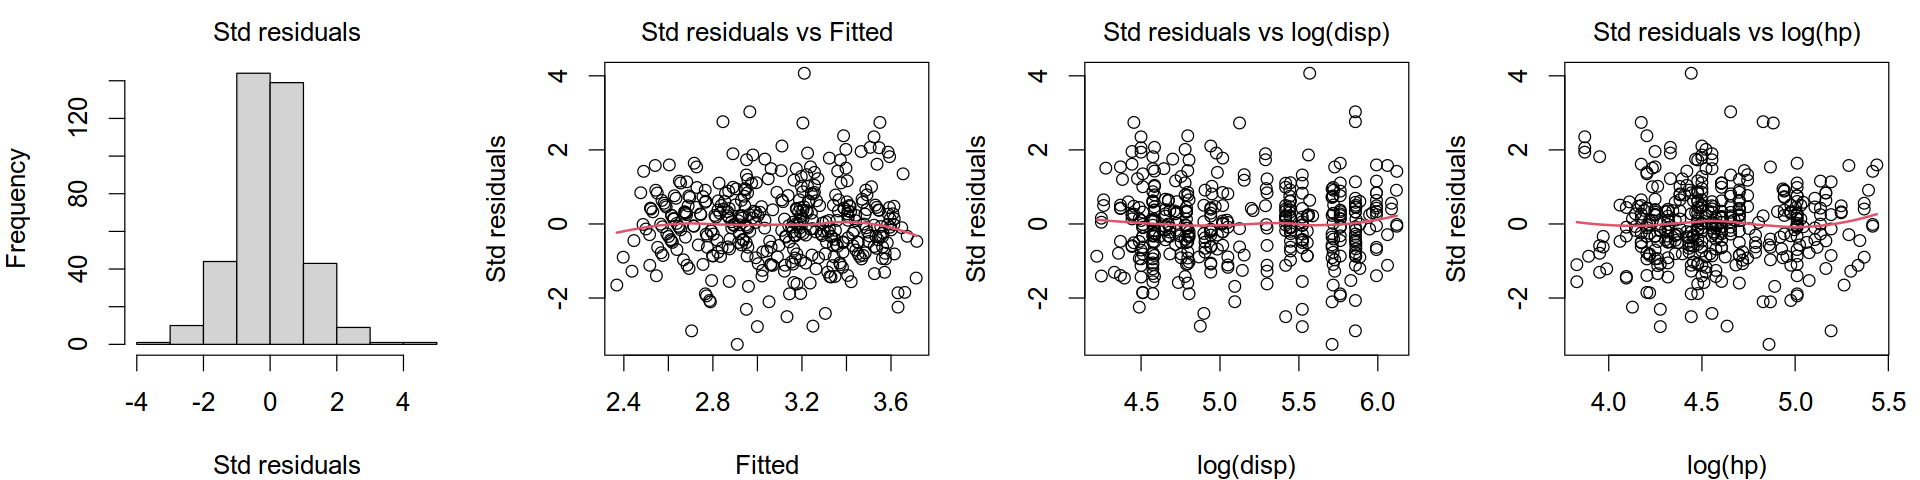

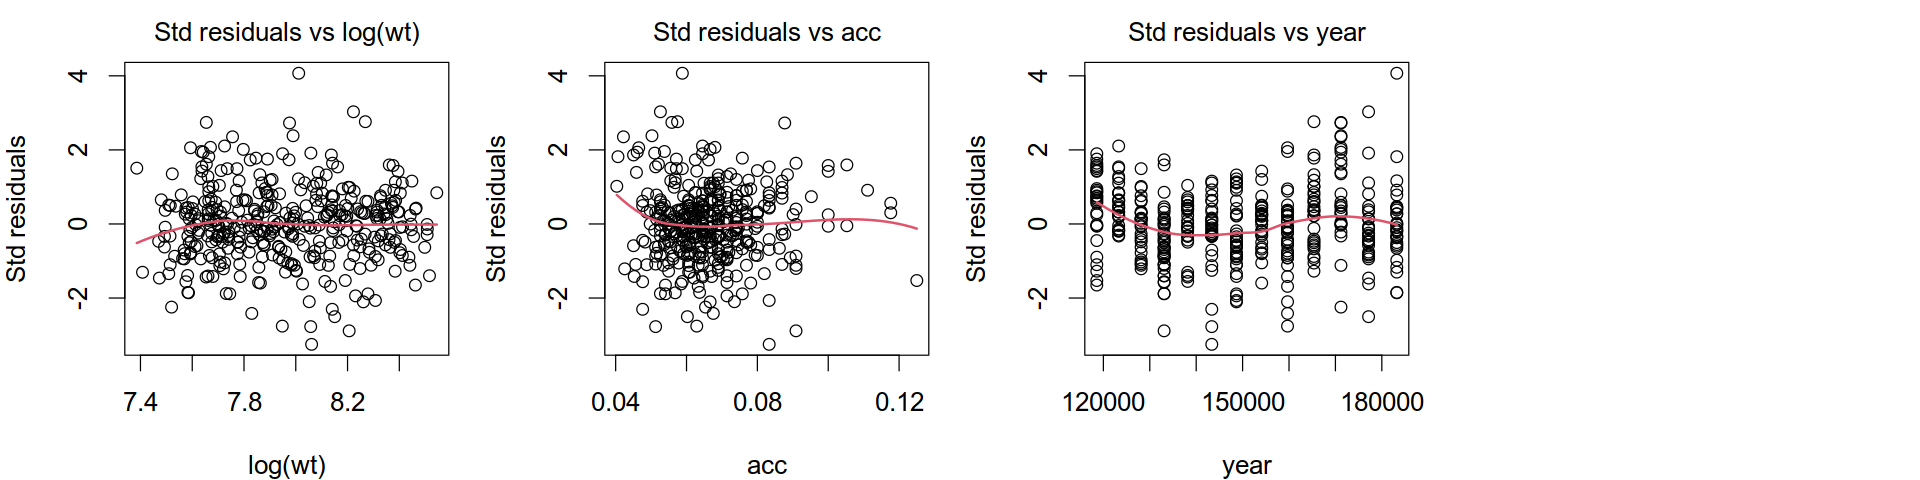

In [13]:
options(repr.plot.width=16, repr.plot.height=4)
par(mfrow = c(1, 4), mar=c(4,4,2,1), cex=1.3)

plot(model)
r.std = rstandard(model)
y.hat = fitted(model)
with(auto,{
    hist(r.std, main="Std residuals", cex.main=1, font.main = 1, xlab="Std residuals")
    resplot(y.hat, r.std, xlab = "Fitted", ylab="Std residuals")
    resplot(log(disp), r.std, xlab = "log(disp)", ylab="Std residuals")
    resplot(log(hp), r.std, xlab = "log(hp)", ylab="Std residuals")
    resplot(log(wt), r.std, xlab = "log(wt)", ylab="Std residuals")
    resplot(I(1/acc), r.std, xlab = "acc", ylab="Std residuals")
    resplot(I(year^2.75), r.std, xlab = "year", ylab="Std residuals")
    }
)

The normality assumptions are met. There are minor deviations in the standardised residuals vs ``acc`` and ``year`` plots, but these are the best results I could get. 

---

### Step 2.

Clean up the data. Find outliers and leverage cases. Recall the rough criterions:

$$
|r_i| > 2\text{ to } 4, \qquad
h_{ii} > 2 \cdot \frac{p+1}{n}, \qquad
D_i > \frac{4}{n-p-1}
$$

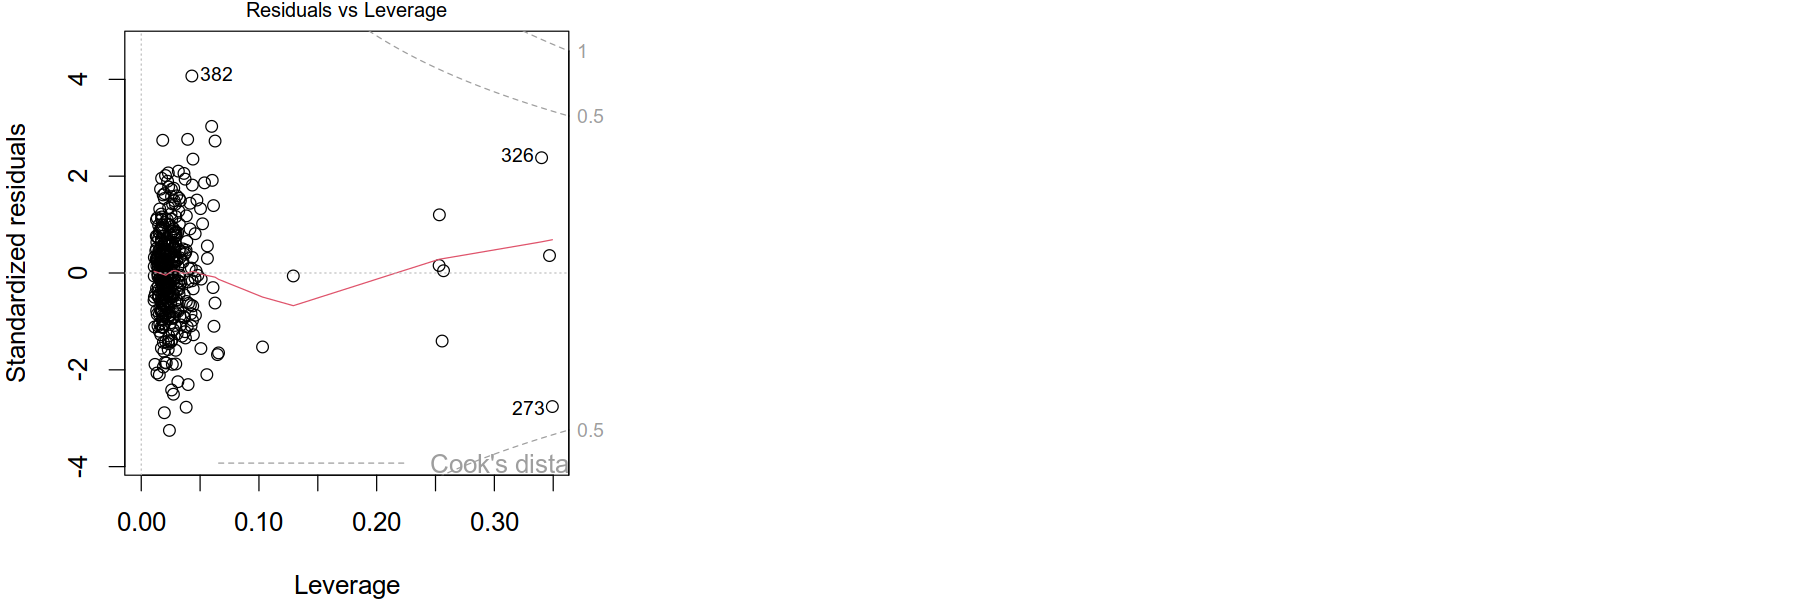

In [14]:
# built-in plot
options(repr.plot.width=15, repr.plot.height=5)
par(mfrow = c(1, 3), mar=c(4,4,1,1), cex=1.3)
plot(model, which=5)

In [15]:
model # the model has 11 slopes and 1 intercept


Call:
lm(formula = log(mpg) ~ log(disp) + log(hp) + log(wt) + I(1/acc) + 
    I(year^2.75) + cyl + origin, data = auto)

Coefficients:
 (Intercept)     log(disp)       log(hp)       log(wt)      I(1/acc)  
   6.993e+00    -6.998e-02    -3.098e-01    -4.337e-01     3.639e+00  
I(year^2.75)          cyl4          cyl5          cyl6          cyl8  
   5.468e-06     2.983e-01     3.578e-01     2.422e-01     2.308e-01  
     origin2       origin3  
   2.067e-02     4.424e-02  


In [16]:
n = nrow(auto) # number of cases
p = 11         # number of slopes

In [17]:
r = rstandard(model)        # standardised residuals
h = hatvalues(model)        # leverages
D = cooks.distance(model)   # Cook's distance

In [18]:
outliers = abs(r) > 3
sum(outliers)               # three potential outliers

[1] 3

In [19]:
leverages = h > 2*(p+1)/n
sum(leverages)              # 16 high-leverage cases! a lot! the threshold is too low

[1] 15

In [20]:
influence = D > 4/(n-p-1)
sum(influence)              # 27 influential cases! a lot! the threshold is too low

[1] 29

In [21]:
sum(outliers & leverages)   # no bad leverages

[1] 0

In [22]:
sum(outliers & influence)   # all three outliers are influential

[1] 3

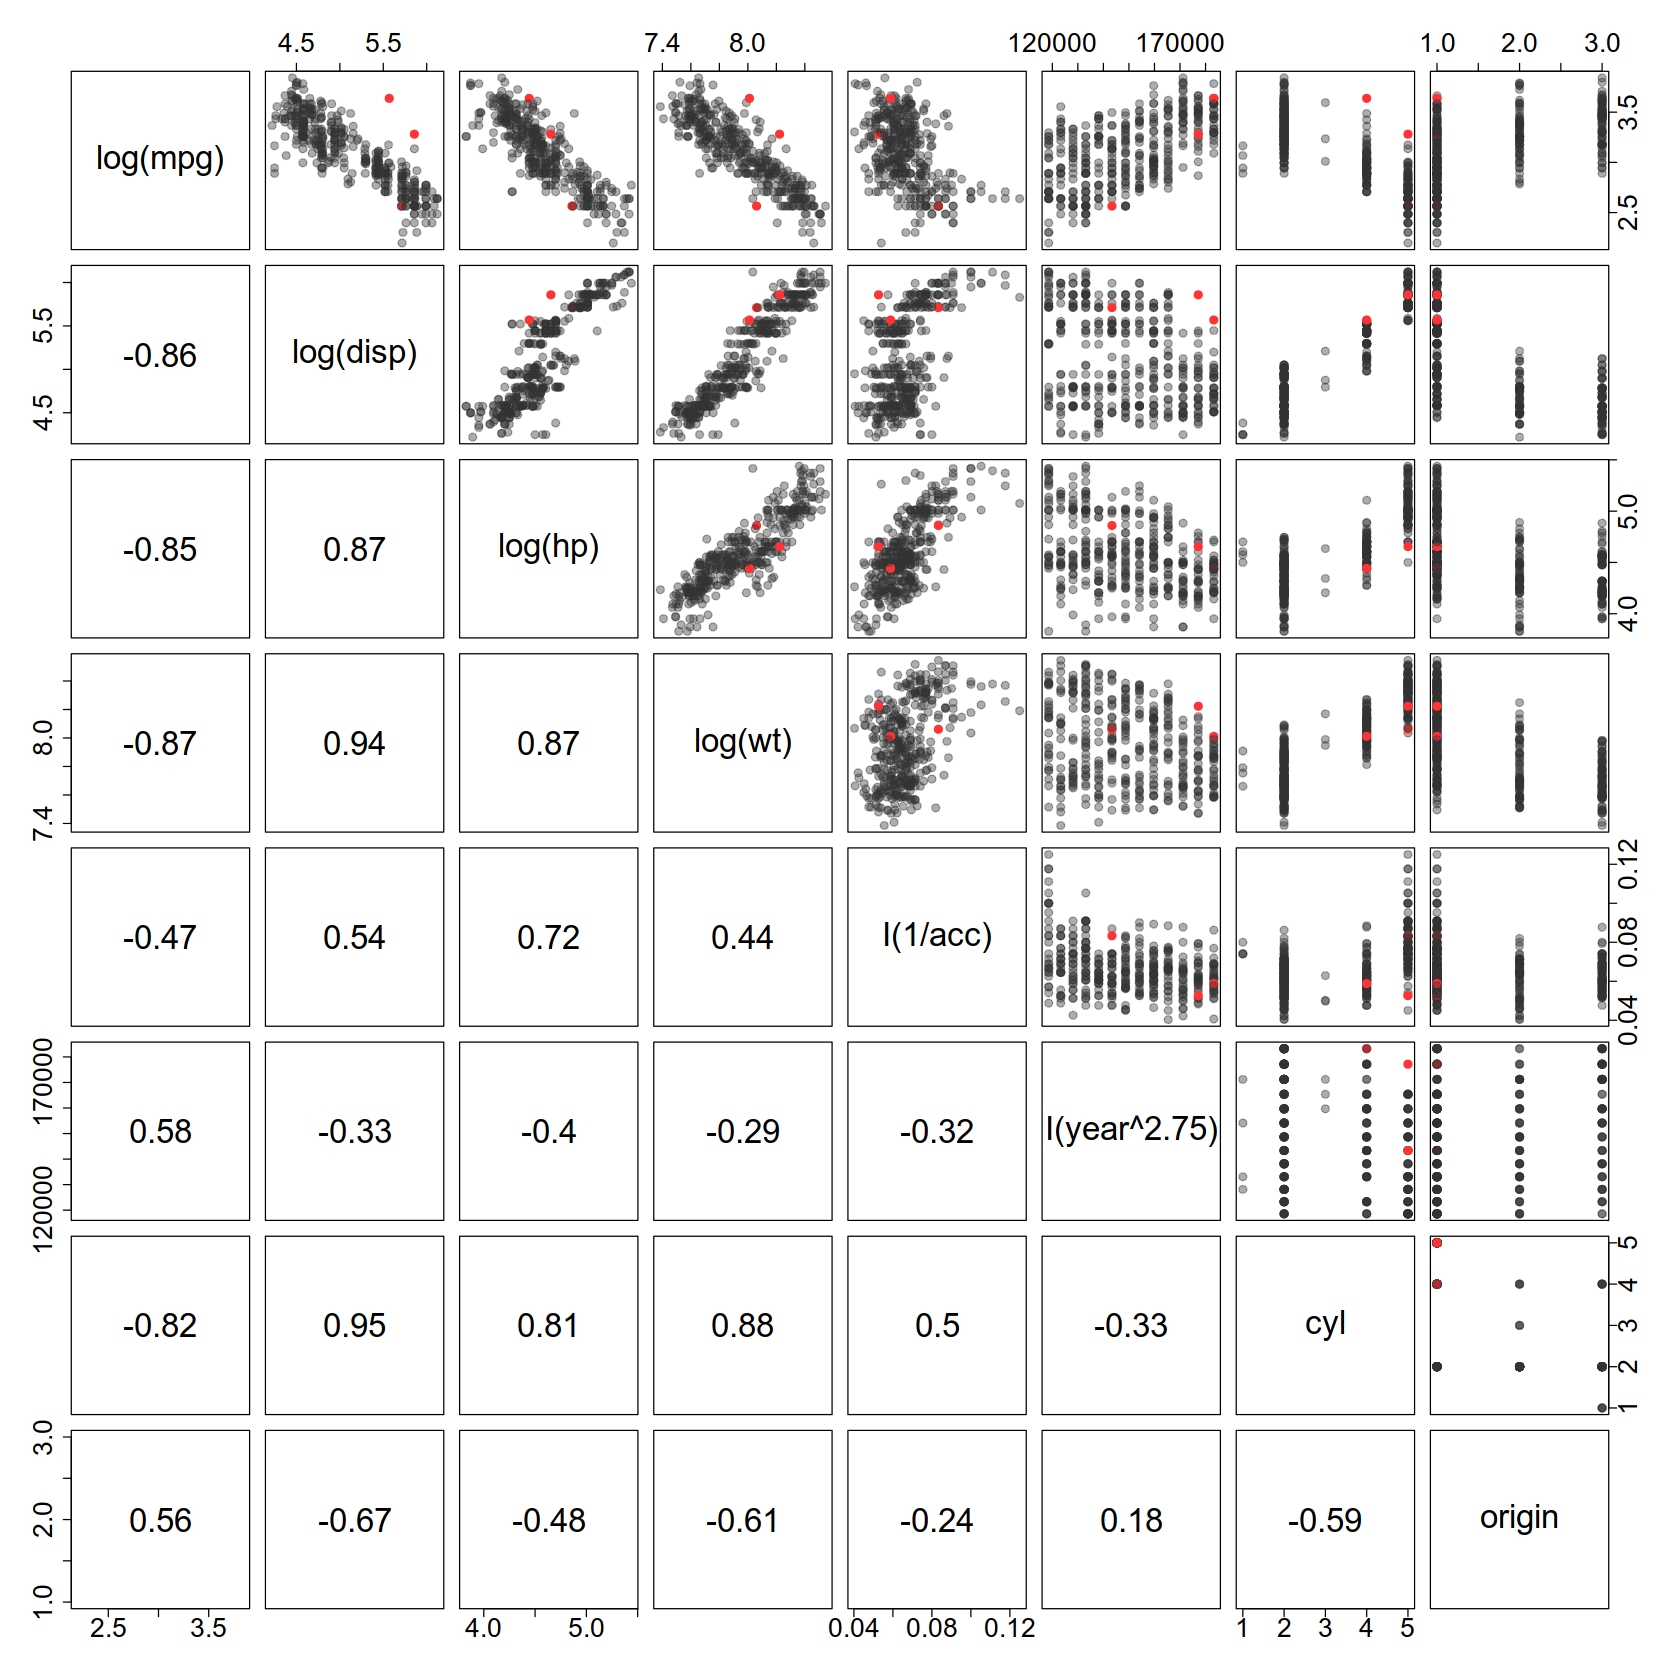

In [23]:
options(repr.plot.width=14, repr.plot.height=14)

# find the location of the outliers in the scatterplot matrix
flag = as.numeric(outliers)

pairs(log(mpg) ~ log(disp) + log(hp) + log(wt) + I(1/acc) + I(year^2.75) + cyl + origin, data=auto, 
      lower.panel=panel.cor, 
      cex.labels=2.5,
      cex=2,
      cex.axis=2,
      pch=20, 
      col=rgb(red=0.2 + flag*0.8, green=0.2, blue=0.2, alpha=0.4 + flag*0.6) # highlight outliers in red
     )

In [24]:
# inspect outliers
auto[outliers,]

,mpg,cyl,disp,hp,wt,acc,year,origin,name
,<dbl>,<fct>,<dbl>,<int>,<int>,<dbl>,<int>,<fct>,<chr>
165,13.0,8,302,129,3169,12,75,1,ford mustang ii
360,26.6,8,350,105,3725,19,81,1,oldsmobile cutlass ls
382,38.0,6,262,85,3015,17,82,1,oldsmobile cutlass ciera (diesel)


The outliers are [Ford Mustang II](https://en.wikipedia.org/wiki/Ford_Mustang_(second_generation)), 
[Oldsmobile Cutclass LS](https://en.wikipedia.org/wiki/Oldsmobile_Cutlass) and 
[Oldsmobile Cutclass Ciera](https://en.wikipedia.org/wiki/Oldsmobile_Cutlass_Ciera)

<table><tr>
    <td>
        <img src="https://s3.amazonaws.com/images.hagerty.com/vehicle/web/30448_1974%20MustangII_front.jpg" alt="Mustang" style="height: 200px;"/>
    </td>
    <td>
        <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/c6/Oldsmobile_Cutlass_LS_%2811515863296%29.jpg/960px-Oldsmobile_Cutlass_LS_%2811515863296%29.jpg" alt="Mustang" style="height: 200px;"/>
    </td>
    <td>
        <img src="https://upload.wikimedia.org/wikipedia/commons/1/10/1996_Oldsmobile_Ciera.jpg" alt="Oldsmobyle" style="height: 140px;"/>
    </td>
</tr></table>

---

### Step 3. 

Find the "best" model.

We split the data 80/20 into a "training" set and a "test" set:

In [25]:
set.seed(13)                       # fix randomisation seed
test_ind = sample(n, size = n/5)   # randomly select 20% of row numbers

test  = auto[test_ind, ]           # test data - "test_ind" rows only
train = auto[-test_ind, ]          # training data - not "test_ind" rows

We start by fitting the "full" model having all predictors:

In [26]:
# full model
model0 = lm(log(mpg) ~ log(disp) + log(hp) + log(wt) + I(1/acc) + I(year^2.75) + cyl + origin, data=train)
summary(model0)


Call:
lm(formula = log(mpg) ~ log(disp) + log(hp) + log(wt) + I(1/acc) + 
    I(year^2.75) + cyl + origin, data = train)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.33921 -0.06417  0.00306  0.05801  0.32460 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   6.947e+00  5.021e-01  13.836  < 2e-16 ***
log(disp)    -7.949e-02  6.854e-02  -1.160 0.247068    
log(hp)      -2.863e-01  6.169e-02  -4.640 5.20e-06 ***
log(wt)      -4.301e-01  1.023e-01  -4.206 3.43e-05 ***
I(1/acc)      3.393e+00  9.266e-01   3.662 0.000296 ***
I(year^2.75)  5.287e-06  3.462e-07  15.273  < 2e-16 ***
cyl4          3.047e-01  6.972e-02   4.369 1.71e-05 ***
cyl5          4.949e-01  1.082e-01   4.574 6.98e-06 ***
cyl6          2.385e-01  8.279e-02   2.881 0.004249 ** 
cyl8          2.292e-01  9.028e-02   2.538 0.011639 *  
origin2       9.993e-03  2.296e-02   0.435 0.663720    
origin3       3.722e-02  2.115e-02   1.760 0.079458 .  
---
Signif. codes:  0 ‘***’ 0.0

The individual t-tests indicate that the ``log(disp)`` predictor is insignificant (p-value is 24.7%) in the presence of the remaining predictors. Hence we remove this predictor and fit a reduced model:

In [27]:
# first reduced model
model1 = lm(log(mpg) ~ log(hp) + log(wt) + I(1/acc) + I(year^2.75) + cyl + origin, data=train)
summary(model1)


Call:
lm(formula = log(mpg) ~ log(hp) + log(wt) + I(1/acc) + I(year^2.75) + 
    cyl + origin, data = train)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.34722 -0.06500  0.00007  0.05944  0.30998 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   7.216e+00  4.452e-01  16.208  < 2e-16 ***
log(hp)      -2.807e-01  6.154e-02  -4.561 7.40e-06 ***
log(wt)      -5.101e-01  7.555e-02  -6.752 7.43e-11 ***
I(1/acc)      2.988e+00  8.587e-01   3.479 0.000576 ***
I(year^2.75)  5.324e-06  3.450e-07  15.433  < 2e-16 ***
cyl4          2.699e-01  6.299e-02   4.285 2.46e-05 ***
cyl5          4.511e-01  1.015e-01   4.447 1.23e-05 ***
cyl6          1.792e-01  6.513e-02   2.751 0.006295 ** 
cyl8          1.600e-01  6.779e-02   2.360 0.018922 *  
origin2       2.307e-02  2.002e-02   1.152 0.250049    
origin3       4.765e-02  1.915e-02   2.488 0.013386 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1047

The individual t-tests indicate that the ``origin2`` dummy variable is insignificant (p-value is 25%) in the presence of the remaining predictors. For simplicity, we remove the ``origin`` predictor overall and fit a further reduced model:

In [28]:
# second reduced model
model2 = lm(log(mpg) ~ log(hp) + log(wt) + I(1/acc) + I(year^2.75) + cyl, data=train)
summary(model2)


Call:
lm(formula = log(mpg) ~ log(hp) + log(wt) + I(1/acc) + I(year^2.75) + 
    cyl, data = train)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.35619 -0.06799  0.00322  0.06081  0.34688 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   7.614e+00  4.170e-01  18.260  < 2e-16 ***
log(hp)      -2.537e-01  6.062e-02  -4.186 3.72e-05 ***
log(wt)      -5.688e-01  7.162e-02  -7.942 3.87e-14 ***
I(1/acc)      2.734e+00  8.561e-01   3.194  0.00155 ** 
I(year^2.75)  5.334e-06  3.324e-07  16.048  < 2e-16 ***
cyl4          2.466e-01  6.231e-02   3.957 9.44e-05 ***
cyl5          4.466e-01  1.005e-01   4.443 1.24e-05 ***
cyl6          1.494e-01  6.446e-02   2.318  0.02113 *  
cyl8          1.332e-01  6.737e-02   1.977  0.04894 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1055 on 305 degrees of freedom
Multiple R-squared:  0.9056,	Adjusted R-squared:  0.9032 
F-statistic: 365.9 on 8 and 305 DF, 

The individual t-tests indicate that dummy variables ``cyl6`` and ``cyl8`` may be less significant (p-values 2.1% and 4.9%) than the remaining predictors. We remove the ``cyl`` predictor overall and fit a further reduced model.

In [29]:
# third reduced model 
model3 = lm(log(mpg) ~ log(hp) + log(wt) + I(1/acc) + I(year^2.75), data=train)
summary(model3)


Call:
lm(formula = log(mpg) ~ log(hp) + log(wt) + I(1/acc) + I(year^2.75), 
    data = train)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.39132 -0.06980  0.00744  0.05790  0.32745 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   8.816e+00  2.704e-01  32.602  < 2e-16 ***
log(hp)      -2.757e-01  6.227e-02  -4.428 1.32e-05 ***
log(wt)      -6.845e-01  5.917e-02 -11.567  < 2e-16 ***
I(1/acc)      2.285e+00  8.688e-01   2.630  0.00897 ** 
I(year^2.75)  5.632e-06  3.483e-07  16.171  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.112 on 309 degrees of freedom
Multiple R-squared:  0.8922,	Adjusted R-squared:  0.8908 
F-statistic: 639.1 on 4 and 309 DF,  p-value: < 2.2e-16


The individual t-tests indicate that ``I(1/acc)`` predictor may be less significant (p-value is 0.9% ) than the remaining predictors. We remove the ``I(1/acc)`` predictor and fit a further reduced model.

In [30]:
# fourth reduced model
model4 = lm(log(mpg) ~ log(hp) + log(wt) + I(year^2.75), data=train)
summary(model4)


Call:
lm(formula = log(mpg) ~ log(hp) + log(wt) + I(year^2.75), data = train)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.37714 -0.07281  0.00830  0.06284  0.33931 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   9.094e+00  2.513e-01  36.193  < 2e-16 ***
log(hp)      -1.548e-01  4.240e-02  -3.651 0.000306 ***
log(wt)      -7.698e-01  4.994e-02 -15.414  < 2e-16 ***
I(year^2.75)  5.625e-06  3.516e-07  16.000  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1131 on 310 degrees of freedom
Multiple R-squared:  0.8898,	Adjusted R-squared:  0.8887 
F-statistic:   834 on 3 and 310 DF,  p-value: < 2.2e-16


There's nothing else to be removed, so we can start comparing the models we have built. We will begin by testing these models on the ``test`` dataset and computing the mean sum of errors squared, $MS_E$, for each of our models:

In [31]:
n.test = nrow(test) # the number of cases in the test dataset

# prediced values of log(mpg) for each model
lmpg0 = predict(model0, newdata = test)
lmpg1 = predict(model1, newdata = test)
lmpg2 = predict(model2, newdata = test)
lmpg3 = predict(model3, newdata = test)
lmpg4 = predict(model4, newdata = test)

# residual standard errors for the test data
MSE0 = sum( (lmpg0 - log(test$mpg))^2 ) / (n.test-12) 
MSE1 = sum( (lmpg1 - log(test$mpg))^2 ) / (n.test-11)
MSE2 = sum( (lmpg2 - log(test$mpg))^2 ) / (n.test-9)
MSE3 = sum( (lmpg3 - log(test$mpg))^2 ) / (n.test-5)
MSE4 = sum( (lmpg4 - log(test$mpg))^2 ) / (n.test-4)

Next, we will use the summary table of each model to get access to the wanted quantities: $\hat\sigma$ and $R^2_{adj}$

In [32]:
# save summary tables into variables
s0 = summary(model0)
s1 = summary(model1)
s2 = summary(model2)
s3 = summary(model3)
s4 = summary(model4)
# Execute this cell. Then write s0$ and press <tab> to see the "inside" variable

In [33]:
# Compare the models. We want to display the following quantities:
# - residual standard errors for the train data - smaller is better
# - residual standard error for the test data - smaller is better
# - R2-adjusted values - bigger is better
# - Akaike Information Criterion (AIC) - smaller is better
# - Bayesian Information Criterion (BIC) - smaller is better
# We could also include F-values and R2, but they are less important/informative

table = data.frame(row.names=c("Full","-log(disp)","-origin","-cyl","-I(1/acc)"),
                   F = c(s0$fstatistic[1],s1$fstatistic[1],s2$fstatistic[1],s3$fstatistic[1],s4$fstatistic[1]),
                   sigma.train = c(s0$sigma,s1$sigma,s2$sigma,s3$sigma,s4$sigma),                
                   sigma.test = sqrt(c(MSE0,MSE1,MSE2,MSE3,MSE4)),                  
                   R2 = c(s0$r.squared,s1$r.squared,s2$r.squared,s3$r.squared,s4$r.squared),   
                   R2.adj = c(s0$adj.r.squared,s1$adj.r.squared,s2$adj.r.squared,s3$adj.r.squared,s4$adj.r.squared),   
                   AIC = c(AIC(model0),AIC(model1),AIC(model2),AIC(model3),AIC(model4)),   
                   BIC = c(BIC(model0),BIC(model1),BIC(model2),BIC(model3),BIC(model4))  
                  )

round(table, 4)

,F,sigma.train,sigma.test,R2,R2.adj,AIC,BIC
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Full,270.7578,0.1047,0.1306,0.9079,0.9046,-512.4698,-463.7277
-log(disp),297.3605,0.1047,0.1297,0.9075,0.9045,-513.0744,-468.0817
-origin,365.8878,0.1055,0.1304,0.9056,0.9032,-510.7146,-473.2207
-cyl,639.1353,0.1120,0.1209,0.8922,0.8908,-476.8255,-454.3291
-I(1/acc),833.9601,0.1131,0.1224,0.8898,0.8887,-471.8751,-453.1282


**Conclusions.** We choose the second reduced model, ``model2``, as our "best" model:

- ``model2`` has $R^2_{adj}$ and AIC values are among the best ones. 

- ``model2`` has the lowest BIC value.

- ``model2`` has the second largest $\hat\sigma_{test}$ value, but it is comparable to the one of the full and first reduced models.

### Variance Inflation Factors

In [34]:
# variation inflation factors are used to spot multicollinearity
# i.e. a near-linear relationship between the predictors
# install.packages("car")

library(car)
vif(model0)

Loading required package: carData



,GVIF,Df,GVIF^(1/(2*Df))
log(disp),38.831488,1,6.231492
log(hp),12.952059,1,3.598897
log(wt),23.762389,1,4.874668
I(1/acc),3.823926,1,1.955486
I(year^2.75),1.359276,1,1.165880
cyl,19.634644,4,1.450868
origin,3.006742,2,1.316813


In [35]:
vif(model2)

,GVIF,Df,GVIF^(1/(2*Df))
log(hp),12.321861,1,3.510251
log(wt),11.484338,1,3.388855
I(1/acc),3.216101,1,1.793349
I(year^2.75),1.234474,1,1.111069
cyl,7.168960,4,1.279181


---